In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [8]:
# import necessary layers  
from tensorflow.keras.layers import Input, Conv2D 
from tensorflow.keras.layers import MaxPool2D, Flatten, Dense 
from tensorflow.keras import Model
# input

input = Input(shape =(300,300,3))
# 1st Conv Block

x = Conv2D (filters =64, kernel_size =3, padding ='same', activation='relu')(input)
x = Conv2D (filters =64, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)
# 2nd Conv Block

x = Conv2D (filters =128, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =128, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)
# 3rd Conv block

x = Conv2D (filters =256, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =256, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =256, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)
# 4th Conv block

x = Conv2D (filters =512, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =512, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =512, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)

# 5th Conv block

x = Conv2D (filters =512, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =512, kernel_size =3, padding ='same', activation='relu')(x)
x = Conv2D (filters =512, kernel_size =3, padding ='same', activation='relu')(x)
x = MaxPool2D(pool_size =2, strides =2, padding ='same')(x)
# Fully connected layers

x = Flatten()(x)
x = Dense(units = 4096, activation ='relu')(x)
x = Dense(units = 4096, activation ='relu')(x)
output = Dense(units = 1000, activation ='softmax')(x)
# creating the model

model = Model (inputs=input, outputs =output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 300, 300, 3)]     0         
                                                                 
 conv2d_13 (Conv2D)          (None, 300, 300, 64)      1792      
                                                                 
 conv2d_14 (Conv2D)          (None, 300, 300, 64)      36928     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 150, 150, 64)     0         
 2D)                                                             
                                                                 
 conv2d_15 (Conv2D)          (None, 150, 150, 128)     73856     
                                                                 
 conv2d_16 (Conv2D)          (None, 150, 150, 128)     147584    
                                                           

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(dir(keras.datasets))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_sys', 'boston_housing', 'cifar10', 'cifar100', 'fashion_mnist', 'imdb', 'mnist', 'reuters']


In [10]:
from keras.applications.vgg16 import VGG16
# load the model
model = VGG16()

In [11]:
from keras.preprocessing.image import load_img
# load an image from file
image = load_img('cat.jpg', target_size=(224, 224))

ImportError: cannot import name 'load_img' from 'keras.preprocessing.image' (/opt/anaconda3/lib/python3.9/site-packages/keras/preprocessing/image.py)

In [12]:
model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [13]:
image = 
model.predict()

IndexError: tuple index out of range

In [14]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds

In [15]:
print(tf.__version__)

2.9.1


In [16]:
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url,
                                   fname='flower_photos',
                                   untar=True)
data_dir = pathlib.Path(data_dir)

228813984/228813984 [==============================] - 19s 0us/step


In [17]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


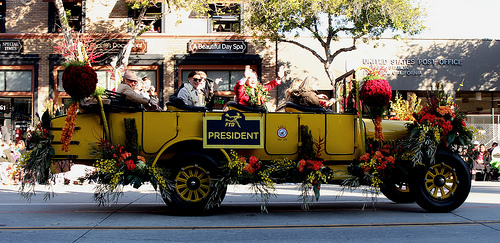

In [18]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[0]))

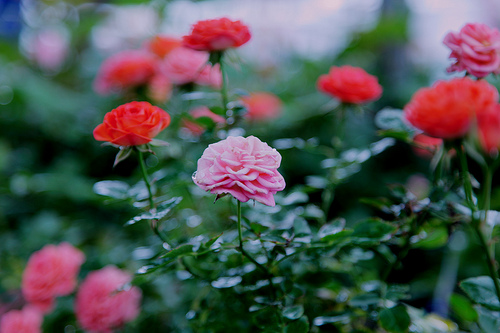

In [19]:
roses = list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[1]))

In [20]:
batch_size = 32
img_height = 180
img_width = 180

In [21]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [22]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [23]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


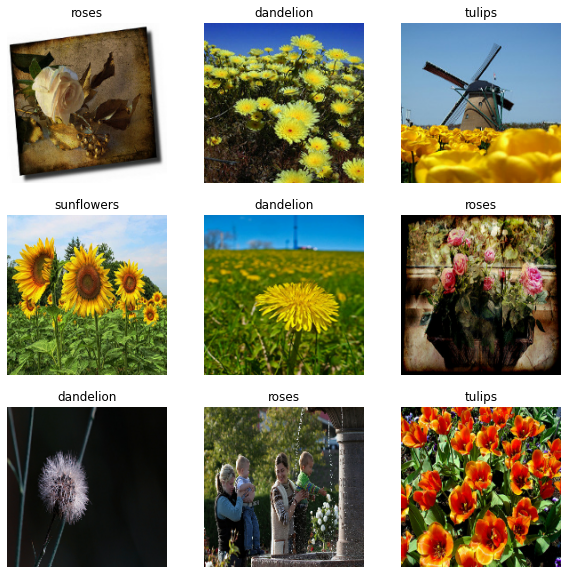

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [25]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [26]:
normalization_layer = tf.keras.layers.Rescaling(1./255)


In [27]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 0.96902645


In [28]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [29]:
num_classes = 5

model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes)
])

In [30]:
model.compile(
  optimizer='adam',
  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

In [31]:
model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=3
)

Epoch 1/3
92/92 [==============================] - 43s 457ms/step - loss: 1.4060 - accuracy: 0.3917 - val_loss: 1.1336 - val_accuracy: 0.5204
Epoch 2/3
92/92 [==============================] - 39s 417ms/step - loss: 1.0867 - accuracy: 0.5484 - val_loss: 1.0264 - val_accuracy: 0.6049
Epoch 3/3
92/92 [==============================] - 38s 412ms/step - loss: 0.9780 - accuracy: 0.6158 - val_loss: 0.9754 - val_accuracy: 0.6063


In [ ]:
model.predict()

In [32]:
from keras.applications.vgg16 import VGG16
model = VGG16(weights='imagenet')
print(model.summary())

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

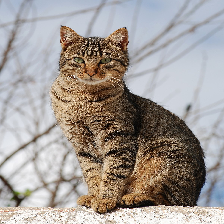

In [33]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input,decode_predictions
import numpy as np

img_path = 'cat.jpg'
#There is an interpolation method to match the source size with the target size
#image loaded in PIL (Python Imaging Library)
img = image.load_img(img_path,color_mode='rgb', target_size=(224, 224))
display(img)

In [34]:
# Converts a PIL Image to 3D Numy Array
x = image.img_to_array(img)
print(x.shape)
# Adding the fouth dimension, for number of images
x = np.expand_dims(x, axis=0)
#print(x)

(224, 224, 3)
[[[[157. 161. 173.]
   [161. 170. 185.]
   [167. 180. 197.]
   ...
   [181. 193. 209.]
   [180. 192. 208.]
   [180. 192. 208.]]

  [[155. 161. 173.]
   [164. 173. 188.]
   [170. 181. 199.]
   ...
   [181. 193. 209.]
   [180. 192. 208.]
   [180. 192. 208.]]

  [[157. 165. 178.]
   [167. 176. 193.]
   [175. 183. 204.]
   ...
   [181. 193. 209.]
   [181. 193. 209.]
   [180. 192. 208.]]

  ...

  [[185. 167. 143.]
   [248. 238. 236.]
   [255. 253. 255.]
   ...
   [216. 211. 205.]
   [233. 228. 224.]
   [255. 253. 249.]]

  [[177. 167. 155.]
   [254. 250. 238.]
   [ 94.  91.  74.]
   ...
   [241. 236. 232.]
   [255. 252. 247.]
   [252. 251. 247.]]

  [[182. 169. 153.]
   [170. 158. 144.]
   [214. 196. 192.]
   ...
   [241. 236. 233.]
   [243. 242. 238.]
   [216. 218. 215.]]]]


In [35]:
#mean centering with respect to Image
x = preprocess_input(x)
features = model.predict(x)
p = decode_predictions(features)

1/1 [==============================] - 1s 527ms/step


In [36]:
print(p)

[[('n02123045', 'tabby', 0.20922315), ('n02123159', 'tiger_cat', 0.18350354), ('n02127052', 'lynx', 0.16416946), ('n02356798', 'fox_squirrel', 0.12295349), ('n02124075', 'Egyptian_cat', 0.105128184)]]
